In [24]:
import time
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt

## Class Function

In [15]:
class MultiArmedBanditEnv(gym.Env):
    def __init__(self, n_arms, means, stds):
        """
        Initialize Multi-Armed Bandit Environment
        
        Args:
        - n_arms (int): Number of arms/actions
        - means (list): True mean rewards for each arm
        - stds (list): Standard deviations of rewards for each arm
        """
        super(MultiArmedBanditEnv, self).__init__()
        self.n_arms = n_arms
        self.means = means
        self.stds = stds
        
        # Action and observation spaces
        self.action_space = spaces.Discrete(self.n_arms)
        self.observation_space = spaces.Discrete(1)
        
        # Track best arm
        self.best_arm = np.argmax(means)
        self.best_mean = means[self.best_arm]
    
    def reset(self):
        """
        Reset the environment
        
        Returns:
        - Initial observation (always 0 in this case)
        """
        return 0
    
    def step(self, action):
        """
        Take a step in the environment by selecting an arm
        
        Args:
        - action (int): Arm to pull
        
        Returns:
        - observation (int): Always 0
        - reward (float): Sampled from Gaussian distribution
        - done (bool): Always True (single-step environment)
        - info (dict): Additional information
        """
        # Sample reward from Gaussian distribution for chosen arm
        reward = np.random.normal(self.means[action], self.stds[action])
        return 0, reward, True, {}

In [16]:
class BanditAgent:
    """Base class for Bandit Strategies"""
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.action_counts = np.zeros(n_arms)
        self.value_estimates = np.zeros(n_arms)
    
    def select_action(self):
        raise NotImplementedError("Subclass must implement abstract method")
    
    def update(self, action, reward):
        raise NotImplementedError("Subclass must implement abstract method")

In [17]:
class GreedyAgent(BanditAgent):
    """Greedy Agent always selects the arm with highest estimated value"""
    def select_action(self):
        return np.argmax(self.value_estimates)
    
    def update(self, action, reward):
        # Update value estimate using incremental mean
        n = self.action_counts[action] + 1
        self.value_estimates[action] += (reward - self.value_estimates[action]) / n
        self.action_counts[action] += 1

In [18]:
class EpsilonGreedyAgent(BanditAgent):
    """Epsilon-Greedy Agent explores with probability epsilon"""
    def __init__(self, n_arms, epsilon=0.1):
        super().__init__(n_arms)
        self.epsilon = epsilon
    
    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)
        return np.argmax(self.value_estimates)
    
    def update(self, action, reward):
        n = self.action_counts[action] + 1
        self.value_estimates[action] += (reward - self.value_estimates[action]) / n
        self.action_counts[action] += 1

class UCBAgent(BanditAgent):
    """Upper Confidence Bound (UCB) Agent"""
    def __init__(self, n_arms, c=2.0):
        super().__init__(n_arms)
        self.total_pulls = 0
        self.c = c
    
    def select_action(self):
        # Ensure each arm is pulled at least once
        for i in range(self.n_arms):
            if self.action_counts[i] == 0:
                return i
        
        # UCB calculation
        ucb_values = (
            self.value_estimates + 
            self.c * np.sqrt(np.log(self.total_pulls) / self.action_counts)
        )
        return np.argmax(ucb_values)
    
    def update(self, action, reward):
        n = self.action_counts[action] + 1
        self.value_estimates[action] += (reward - self.value_estimates[action]) / n
        self.action_counts[action] += 1
        self.total_pulls += 1

class ThompsonSamplingAgent(BanditAgent):
    """Thompson Sampling Agent using Gaussian-Normal conjugate prior"""
    def __init__(self, n_arms, mu0=0, sigma0=1, sigma_reward=1):
        super().__init__(n_arms)
        # Prior parameters for each arm
        self.mu0 = mu0  # Prior mean
        self.sigma0 = sigma0  # Prior standard deviation
        self.sigma_reward = sigma_reward  # Known reward standard deviation
        
        # Posterior parameters
        self.mu_posts = np.full(n_arms, mu0)
        self.sigma_posts = np.full(n_arms, sigma0)
    
    def select_action(self):
        # Sample from posterior distributions
        samples = np.random.normal(self.mu_posts, self.sigma_posts)
        return np.argmax(samples)
    
    def update(self, action, reward):
        # Update posterior using Gaussian-Normal conjugate prior
        mu0, sigma0 = self.mu0, self.sigma0
        sigma_reward = self.sigma_reward
        n = self.action_counts[action] + 1
        
        # Compute posterior mean and variance
        sigma_post_inv = 1/sigma0**2 + n/sigma_reward**2
        sigma_post = 1 / np.sqrt(sigma_post_inv)
        
        mu_post = sigma_post**2 * (mu0/sigma0**2 + n*reward/sigma_reward**2)
        
        # Update posterior for this arm
        self.mu_posts[action] = mu_post
        self.sigma_posts[action] = sigma_post
        
        self.value_estimates[action] += (reward - self.value_estimates[action]) / n
        self.action_counts[action] += 1

In [22]:
def run_experiment(env, agent, num_steps=1000):
    rewards = []
    optimal_action_counts = []
    
    for _ in range(num_steps):
        # Select action
        action = agent.select_action()
        
        # Take step in environment
        _, reward, _, _ = env.step(action)
        
        # Update agent
        agent.update(action, reward)
        
        # Record results
        rewards.append(reward)
        optimal_action_counts.append(int(action == env.best_arm))
    
    return rewards, optimal_action_counts

In [23]:
def plot_results(results, best_mean):
    plt.figure(figsize=(15, 10))
    
    # Cumulative Rewards
    plt.subplot(2, 2, 1)
    for name, (rewards, _) in results.items():
        plt.plot(np.cumsum(rewards), label=name)
    plt.title('Cumulative Rewards')
    plt.xlabel('Steps')
    plt.ylabel('Cumulative Reward')
    plt.legend()
    
    # Average Rewards
    plt.subplot(2, 2, 2)
    for name, (rewards, _) in results.items():
        plt.plot(np.convolve(rewards, np.ones(50)/50, mode='valid'), label=name)
    plt.title('Average Rewards (50-step Moving Average)')
    plt.xlabel('Steps')
    plt.ylabel('Average Reward')
    plt.legend()
    
    # Optimal Action Percentage
    plt.subplot(2, 2, 3)
    for name, (_, optimal_counts) in results.items():
        plt.plot(np.cumsum(optimal_counts) / (np.arange(len(optimal_counts)) + 1) * 100, label=name)
    plt.title('Optimal Action Percentage')
    plt.xlabel('Steps')
    plt.ylabel('% Optimal Action')
    plt.legend()
    
    # Regret
    plt.subplot(2, 2, 4)
    for name, (rewards, _) in results.items():
        cumulative_rewards = np.cumsum(rewards)
        optimal_rewards = np.arange(1, len(rewards) + 1) * best_mean
        plt.plot(optimal_rewards - cumulative_rewards, label=name)
    plt.title('Cumulative Regret')
    plt.xlabel('Steps')
    plt.ylabel('Regret')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

True Arm Means: [1.0, 1.5, 2.0, 2.5, 3.0]
Best Arm: 4


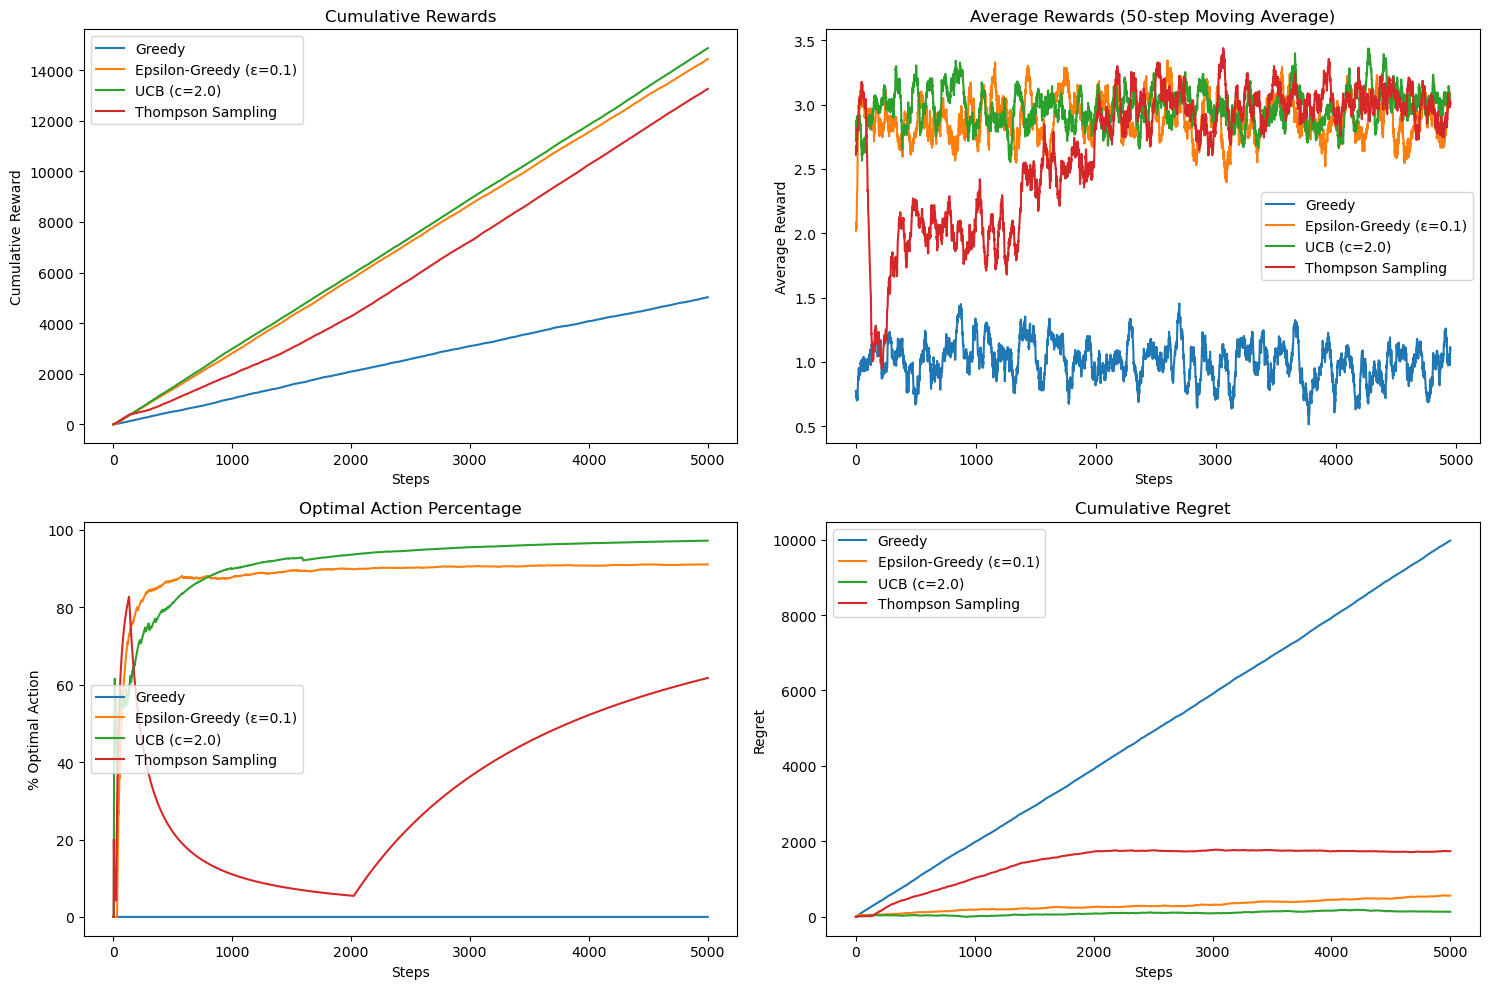

In [21]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Environment setup
n_arms = 5
means = [1.0, 1.5, 2.0, 2.5, 3.0]
stds = [1.0, 1.0, 1.0, 1.0, 1.0]
env = MultiArmedBanditEnv(n_arms=n_arms, means=means, stds=stds)

# Print true means
print("True Arm Means:", means)
print("Best Arm:", env.best_arm)

# Experiment parameters
num_steps = 5000

# Run experiments with different agents
results = {
    'Greedy': run_experiment(env, GreedyAgent(n_arms), num_steps),
    'Epsilon-Greedy (ε=0.1)': run_experiment(env, EpsilonGreedyAgent(n_arms, epsilon=0.1), num_steps),
    'UCB (c=2.0)': run_experiment(env, UCBAgent(n_arms), num_steps),
    'Thompson Sampling': run_experiment(env, ThompsonSamplingAgent(n_arms), num_steps)
}

# Plot results
plot_results(results, env.best_mean)